# **Imports**

In [1]:
import cv2 as cv
import matplotlib.pyplot as plt

(534, 800, 3)


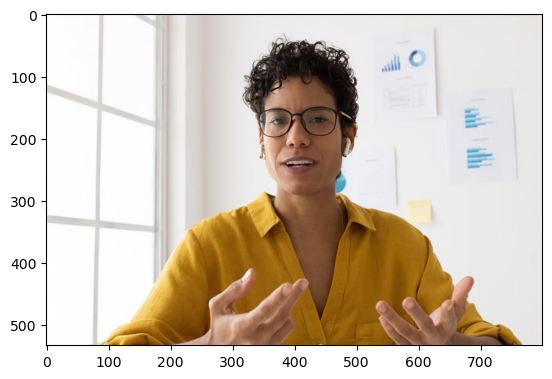

In [2]:
image_bgr = cv.imread(r'images\desafio_1.jpeg')
image_rgb = cv.cvtColor(image_bgr, cv.COLOR_BGR2RGB)
print(image_rgb.shape)
plt.imshow(image_rgb)

(534, 800)


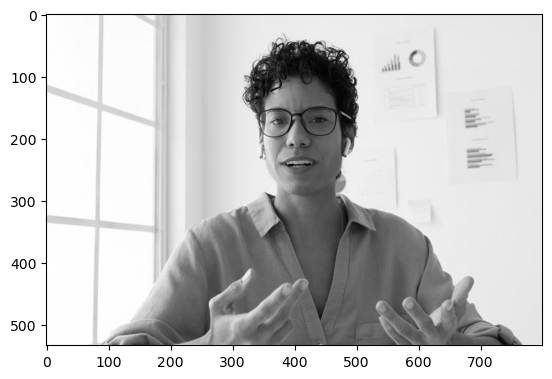

In [3]:
image_gray = cv.cvtColor(image_rgb, cv.COLOR_RGB2GRAY)
print(image_gray.shape)
plt.imshow(image_gray, cmap='gray')

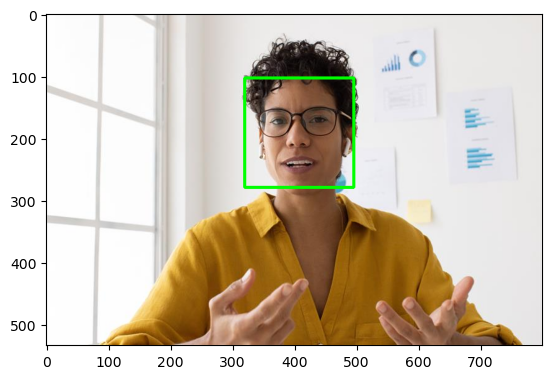

In [9]:
detec = cv.CascadeClassifier(r'models\haarcascade_frontalface_default.xml')
face = detec.detectMultiScale(image_gray, 1.3, 3)
copy_image_rgb = image_rgb.copy()

padding = 10

for (x, y, larg, alt) in face:
    ret = cv.rectangle(copy_image_rgb, (x,y), (x+larg, y+alt),(0,255,0), 3)
    y, height = max(0, y-padding), min(y+alt+padding, image_rgb.shape[0])
    x, width = max(0, x-padding), min(x+larg+padding, image_rgb.shape[1])
    face_img = image_rgb[y:height, x:width, :]

plt.imshow(copy_image_rgb)

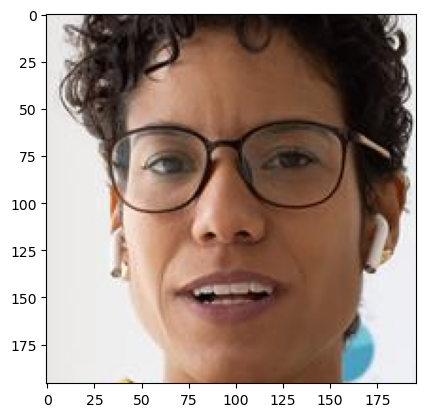

In [10]:
plt.imshow(face_img)

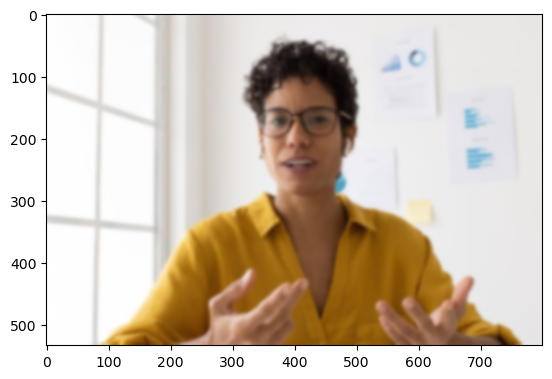

In [11]:
blured_img = cv.GaussianBlur(image_rgb, (15,15), 0)
plt.imshow(blured_img)

(np.float64(-0.5), np.float64(799.5), np.float64(533.5), np.float64(-0.5))

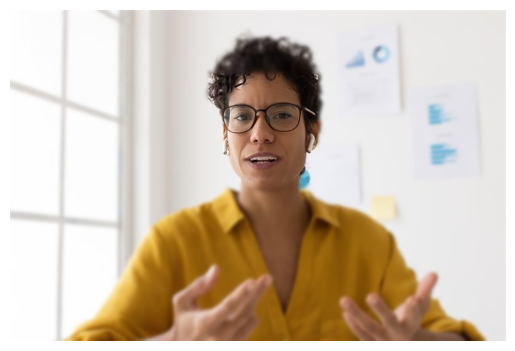

In [14]:
final_image = blured_img
for (x, y, larg, alt) in face:
    final_image[y:y+alt, x:x+larg] = image_rgb[y:y+alt, x:x+larg]
plt.imshow(final_image)
plt.axis('off')